# 09 — Galaxy cluster lensing (NFW + cluster members)

Galaxy clusters are the largest gravitationally-bound objects and the strongest gravitational lenses. We model the cluster mass as

* a **smooth NFW dark-matter halo** (the dominant component),
* one or more **cluster-member galaxies** (SIE),
* an **external shear** capturing the residual large-scale tide.

Then we map the convergence, the critical lines and the multi-image regions, and compare to the MACS J1206 HST stack.

In [1]:
# Bootstrap: make `lensing` importable when running notebooks/ directly.
import sys
from pathlib import Path
repo = Path.cwd().resolve().parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import lensing as gl
# Device-agnostic: prefer MPS (Apple GPU) → CUDA → CPU.
# Pass device="cpu" if you need to force the CPU path (e.g. for
# operators that have no MPS kernel yet, or for reproducibility).
device, dtype = gl.config.setup(seed=42)
print(f"using device: {device}")


/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device: mps


## 1. Build the cluster as a `CompositeLens`

In [2]:
halo = gl.lens.NFW(theta_s=30.0, kappa_s=0.4, center_x=0., center_y=0.)
galA = gl.lens.SIE(theta_E=2.5, q=0.7, pa=0.4, center_x=-8., center_y=+5.)
galB = gl.lens.SIE(theta_E=2.0, q=0.6, pa=-0.3, center_x=+10., center_y=-3.)
shear = gl.lens.ExternalShear(gamma1=0.04, gamma2=-0.02)
cluster = gl.lens.CompositeLens([halo, galA, galB, shear])


## 2. Convergence map

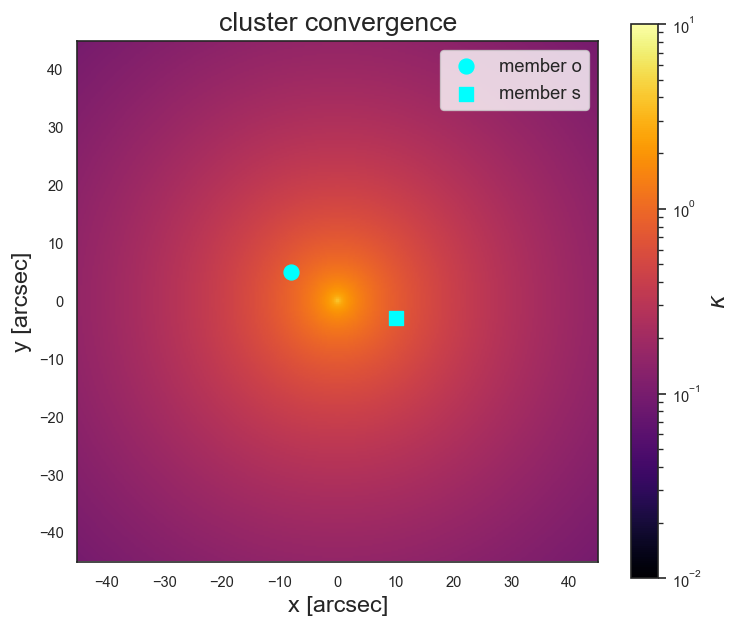

In [3]:
xy = gl.data.coordinate_grid(npix=300, deltapix=0.3)
with torch.no_grad():
    kappa = halo.kappa(xy[0], xy[1])  # halo dominates kappa
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(7, 6))
half = 0.5 * 300 * 0.3
im = ax.imshow(kappa.numpy(), origin='lower', cmap='inferno',
               extent=(-half, half, -half, half),
               norm=LogNorm(vmin=1e-2, vmax=10))
plt.colorbar(im, ax=ax, label=r'$\kappa$')
for comp, marker in [(galA, 'o'), (galB, 's')]:
    ax.scatter(float(comp.center_x), float(comp.center_y),
               marker=marker, c='cyan', s=80, label=f'member {marker}')
ax.set(xlabel='x [arcsec]', ylabel='y [arcsec]', title='cluster convergence')
ax.legend(); plt.show()


## 3. Numerical critical curves (det A = 0)

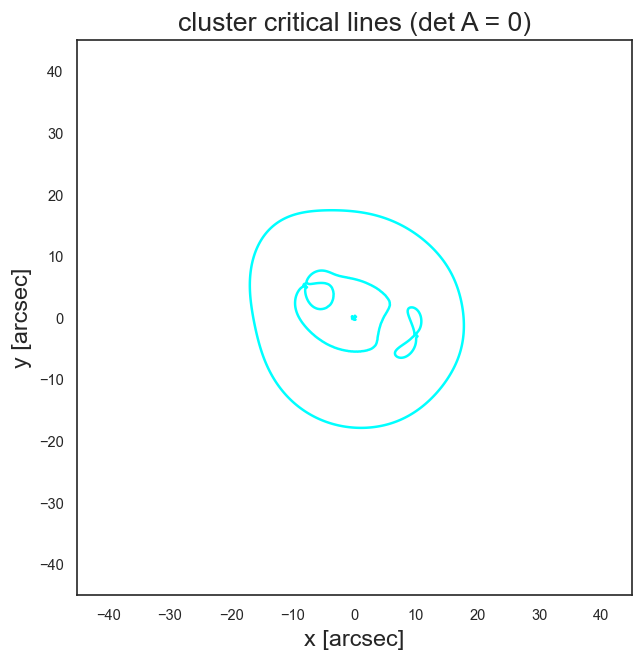

In [4]:
xy = gl.data.coordinate_grid(npix=600, deltapix=0.15)
with torch.no_grad():
    bx, by = cluster.ray_trace(xy[0], xy[1])
    # finite-difference Jacobian along x and y
    dx = 0.15
    bx_xp, _ = cluster.ray_trace(xy[0] + dx, xy[1])
    _, by_yp = cluster.ray_trace(xy[0], xy[1] + dx)
    bx_yp, _ = cluster.ray_trace(xy[0], xy[1] + dx)
    _, by_xp = cluster.ray_trace(xy[0] + dx, xy[1])
    A11 = (bx_xp - bx) / dx
    A22 = (by_yp - by) / dx
    A12 = (bx_yp - bx) / dx
    A21 = (by_xp - by) / dx
    detA = A11 * A22 - A12 * A21

fig, ax = plt.subplots(figsize=(7, 6))
half = 0.5 * 600 * 0.15
ax.contour(xy[0].numpy(), xy[1].numpy(), detA.numpy(),
           levels=[0.0], colors='cyan', linewidths=1.5)
ax.set_aspect('equal')
ax.set(xlabel='x [arcsec]', ylabel='y [arcsec]',
       title='cluster critical lines (det A = 0)',
       xlim=(-half, half), ylim=(-half, half))
plt.show()


## 4. Real-data reference: MACS J1206

The course materials include an HST stack of the cluster MACS J1206; we plot it side by side with our toy convergence.

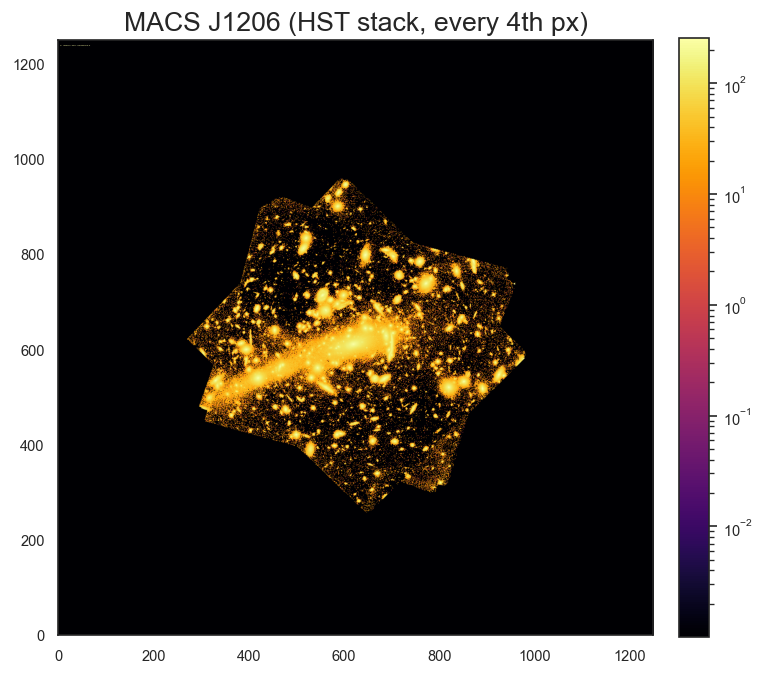

In [5]:
from astropy.io import fits

macs_path = repo / 'data' / 'raw' / 'macs1206_stack.fits'
if macs_path.exists():
    with fits.open(macs_path) as hdul:
        # The HST stack stores three RGB channels in HDU 1..3;
        # HDU[0] is empty PRIMARY metadata. Use the first image HDU.
        img_hdu = next((h for h in hdul if h.data is not None), None)
        macs = np.asarray(img_hdu.data, dtype=np.float32)
    macs = np.nan_to_num(macs)
    fig, ax = plt.subplots(figsize=(7, 7))
    gl.viz.imshow_log(macs[::4, ::4] - np.median(macs) + 1e-3, ax=ax,
                      title='MACS J1206 (HST stack, every 4th px)')
    plt.show()
else:
    print("No MACS J1206 FITS found in data/raw/.")
